In [338]:
import customfunctions as ctf
import pandas as pd
import numpy as np
import heartpy as hp
import neurokit2 as nk
import prepro as prep  # Custom functions for preprocessing
import os
import glob
from pathlib import Path
from scipy.ndimage import uniform_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
from scipy import stats

# Parameters

### Preprocessing parameters

In [339]:
# BVP preprocessing
bvp_prepro_winsz = 10
bvp_prepro_ovlap = 0.02
bvp_fs = 64

# EDA preprocessing
eda_fs = 4
iter_num = 7

### Processing parameters

In [466]:
basalscene = 0
targetscene = 3
# Note, subject 10 does not have scene 2 nor 3 data
subjects = [1, 2, 3, 4, 6, 8, 9]
winsz = 90
ovlap = 0.5
# Outlier removal method, either iqr_outlier, mod_zscore_outlier (both applicable in non-normal data) or winsorization (winsor_outlier)
outliermeth = 'quant_outlier'
# Outlier treatment strategy, either elimination ('elim') or imputation ('impute')
outliertreatment = 'elim'
p_low=0.5
p_high=0.95
# Normalization type, either z-score ('zscore'), mean ('mean'), minmax scaling ('minmax'), robust scaling ('robust')
normtype = 'zscore'
base_dir = Path().resolve()

# Data import function

In [467]:
folderpath = os.path.join(base_dir, "..", "RawData")
folderpath = os.path.abspath(folderpath)


def dataimport(subjects, folderpath, scene):
    bvp_rawdata_list = []
    eda_rawdata_list = []

    for subject in subjects:
        subject_str = f"S{subject}" if subject == 10 else f"S{subject:02d}"
        pattern = os.path.join(
            folderpath,
            f"S{subject}",
            "Empatica",
            f"P300_{subject_str}R0{scene}*",
            "Raw",
        )
        matched_folders = glob.glob(pattern)
        raw_folder = matched_folders[0]
        bvp_dataholder = pd.read_csv(os.path.join(raw_folder, r"fileBVP.csv")).drop(
            "Datetime", axis=1
        )
        eda_dataholder = pd.read_csv(os.path.join(raw_folder, r"fileEDA.csv")).drop(
            "Datetime", axis=1
        )

        bvp_dataholder.insert(
            loc=0, column="Subject", value=[subject] * len(bvp_dataholder)
        )
        eda_dataholder.insert(
            loc=0, column="Subject", value=[subject] * len(eda_dataholder)
        )

        bvp_rawdata_list.append(bvp_dataholder)
        eda_rawdata_list.append(eda_dataholder)

    bvp_rawdata_df = pd.concat(bvp_rawdata_list, ignore_index=True)
    eda_rawdata_df = pd.concat(eda_rawdata_list, ignore_index=True)

    return bvp_rawdata_df, eda_rawdata_df


basal_bvp_rawdata, basal_eda_rawdata = dataimport(
    subjects, folderpath, scene=basalscene
)
tscene_bvp_rawdata, tscene_eda_rawdata = dataimport(
    subjects, folderpath, scene=targetscene
)

# Preprocessing function

In [468]:
def preprocess(subjects, bvp_df, eda_df, bvp_fs, eda_fs, winsz, ovlap, iter_num):
    bvp_prepdata_list = []
    eda_prepdata_list = []
    for subject in subjects:
        bvp_dataholder = pd.DataFrame(
            prep.preprocess_bvp(
                sig=bvp_df[bvp_df["Subject"] == subject]["valueBVP"],
                fs=bvp_fs,
                winsz=winsz,
                ovlap=ovlap,
            ),
            columns=["valueBVP"],
        )
        eda_dataholder = pd.DataFrame(
            prep.preprocess_eda(
                sig=eda_df[eda_df["Subject"] == subject]["valueEDA"],
                fs=eda_fs,
                iter_num=iter_num,
                verbose=False,
            )[0],
            columns=["valueEDA"],
        )

        bvp_dataholder.insert(
            loc=0, column="Subject", value=[subject] * len(bvp_dataholder)
        )
        eda_dataholder.insert(
            loc=0, column="Subject", value=[subject] * len(eda_dataholder)
        )

        bvp_prepdata_list.append(bvp_dataholder)
        eda_prepdata_list.append(eda_dataholder)

    bvp_prepdata_df = pd.concat(bvp_prepdata_list, ignore_index=True)
    eda_prepdata_df = pd.concat(eda_prepdata_list, ignore_index=True)

    return bvp_prepdata_df, eda_prepdata_df


basal_bvp_prepdata, basal_eda_prepdata = preprocess(
    subjects=subjects,
    bvp_df=basal_bvp_rawdata,
    eda_df=basal_eda_rawdata,
    bvp_fs=bvp_fs,
    eda_fs=eda_fs,
    winsz=bvp_prepro_winsz,
    ovlap=bvp_prepro_ovlap,
    iter_num=iter_num,
)

tscene_bvp_prepdata, tscene_eda_prepdata = preprocess(
    subjects=subjects,
    bvp_df=tscene_bvp_rawdata,
    eda_df=tscene_eda_rawdata,
    bvp_fs=bvp_fs,
    eda_fs=eda_fs,
    winsz=bvp_prepro_winsz,
    ovlap=bvp_prepro_ovlap,
    iter_num=iter_num,
)


# Processing function

In [469]:
import warnings
def get_bvp_feats(window, smooth_window, fs):
    wd = {}
    wd = hp.peakdetection.detect_peaks(
        window, smooth_window, ma_perc=20, sample_rate=fs
    )
    wd = hp.analysis.calc_rr(wd["peaklist"], sample_rate=fs, working_data=wd)
    wd = hp.peakdetection.check_peaks(
        wd["RR_list"], wd["peaklist"], window[wd["peaklist"]], working_data=wd
    )
    wd = hp.analysis.clean_rr_intervals(working_data=wd, method="quotient-filter")
    rr_list = wd["RR_list_cor"]
    rr_diff = np.diff(rr_list)
    rr_sqdiff = np.power(rr_diff, 2)
    wd, msrs = hp.analysis.calc_ts_measures(
        rr_list, rr_diff, rr_sqdiff, working_data=wd
    )
    wd, msrs = hp.analysis.calc_fd_measures(measures=msrs, working_data=wd)
    bvp_feats = pd.DataFrame([msrs])[
        [
            "bpm",
            "sdnn",
            'rmssd',
            "pnn50",
            "hr_mad",
            "lf",
            "hf",
            "lf/hf",
            "p_total",
            "lf_nu",
            "hf_nu",
        ]
    ]

    return bvp_feats


def get_eda_feats(window, fs):
    signals, info = nk.eda_process(window, fs)
    mean_eda = np.nanmean(window)
    mean_tonic = np.nanmean(signals["EDA_Tonic"])
    scr_peak_count = np.nansum(signals["SCR_Peaks"])
    scr_sum_amp = np.nansum(info["SCR_Amplitude"])
    scr_mean_amp = np.nanmean(info["SCR_Amplitude"])
    scr_mean_risetime = np.nanmean(info["SCR_RiseTime"])
    scr_mean_recoverytime = np.nanmean(info["SCR_RecoveryTime"])

    eda_feats = pd.DataFrame(
        [
            {
                "mean_eda": mean_eda,
                "mean_tonic": mean_tonic,
                "scr_peak_count": scr_peak_count,
                "scr_sum_amp": scr_sum_amp,
                "scr_mean_amp": scr_mean_amp,
                "scr_mean_risetime": scr_mean_risetime,
                "scr_mean_recoverytime": scr_mean_recoverytime,
            }
        ]
    )

    return eda_feats


def process(subjects, bvp_prepdata_df, eda_prepdata_df, bvp_fs, eda_fs, ovlap, winsz):
    feat_mat_list = []
    for subject in subjects:
        # BVP
        bvp_probe = np.array(
            bvp_prepdata_df[bvp_prepdata_df["Subject"] == subject]["valueBVP"]
        )
        bvp_smooth = uniform_filter1d(
            bvp_probe, size=int(0.75 * bvp_fs), mode="nearest"
        )
        bvp_windowed = ctf.timewindowpadded(
            data=bvp_probe, fs=bvp_fs, ovlap=ovlap, winsz=winsz
        )
        smooth_windowed = ctf.timewindowpadded(
            data=bvp_smooth, fs=bvp_fs, ovlap=ovlap, winsz=winsz
        )
        bvp_holder_list = []
        for windnum in range(0,bvp_windowed.shape[0]):
            bvp_feat_row = get_bvp_feats(
                window=bvp_windowed[windnum],
                smooth_window=smooth_windowed[windnum],
                fs=bvp_fs,
            )
            bvp_holder_list.append(bvp_feat_row)
        bvp_holder_df = pd.concat(bvp_holder_list, ignore_index=True)

        # EDA
        eda_probe = np.array(
            eda_prepdata_df[eda_prepdata_df["Subject"] == subject]["valueEDA"]
        )
        eda_windowed = ctf.timewindowpadded(
            data=eda_probe, fs=eda_fs, ovlap=ovlap, winsz=winsz
        )
        eda_holder_list = []
        for windnum in range(0,eda_windowed.shape[0]):
            eda_feat_row = get_eda_feats(window=eda_windowed[windnum], fs=eda_fs)
            eda_holder_list.append(eda_feat_row)
        eda_holder_df = pd.concat(eda_holder_list, ignore_index=True)

        valid_len = min(len(bvp_holder_df), len(eda_holder_df))
        joined_df = pd.concat([bvp_holder_df.iloc[:valid_len], eda_holder_df.iloc[:valid_len]], axis=1)
        joined_df.insert(loc=0, column="Subject", value=[subject] * len(joined_df))
        feat_mat_list.append(joined_df)
        
    feat_mat_df = pd.concat(feat_mat_list, ignore_index=True)
    return feat_mat_df


basal_feat_mat = process(
    subjects=subjects,
    bvp_prepdata_df=basal_bvp_prepdata,
    eda_prepdata_df=basal_eda_prepdata,
    bvp_fs=bvp_fs,
    eda_fs=eda_fs,
    ovlap=ovlap,
    winsz=winsz,
)

tscene_feat_mat = process(
    subjects=subjects,
    bvp_prepdata_df=tscene_bvp_prepdata,
    eda_prepdata_df=tscene_eda_prepdata,
    bvp_fs=bvp_fs,
    eda_fs=eda_fs,
    ovlap=ovlap,
    winsz=winsz,
)

warnings.filterwarnings('ignore')

## Elimination of bad features

basal_feat_mat.drop(['sdnn','mean_eda',"mean_tonic","lf","hf","lf_nu","hf_nu","p_total","scr_sum_amp","scr_mean_amp","scr_mean_risetime","scr_mean_recoverytime"],axis=1,inplace=True)
tscene_feat_mat.drop(['sdnn','mean_eda',"mean_tonic","lf","hf","lf_nu","hf_nu","p_total","scr_sum_amp","scr_mean_amp","scr_mean_risetime","scr_mean_recoverytime"],axis=1,inplace=True)

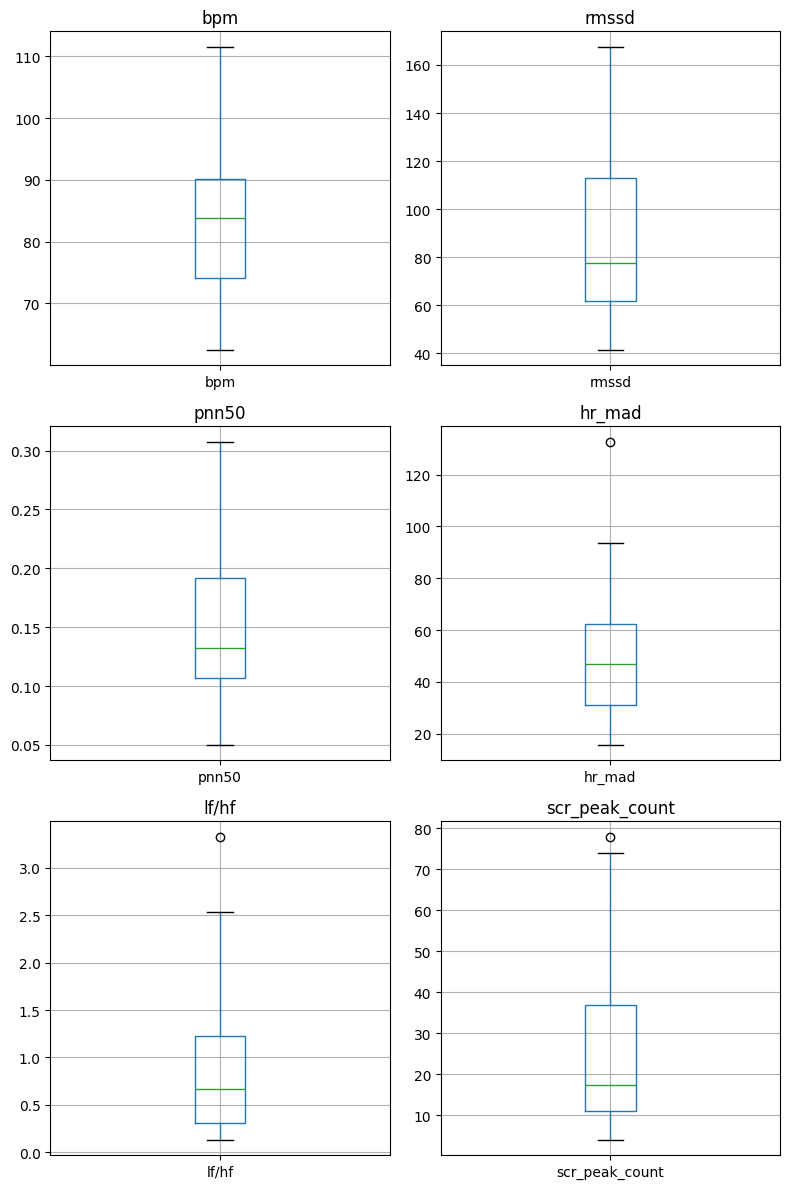

In [470]:
import math

# Suponiendo que tu df es basal_outlier_treated
# 1. Quitar columna no numérica
num = basal_feat_mat.drop(columns=['Subject'], errors='ignore').select_dtypes(include='number')

# 2. Número de columnas a graficar
n_cols = num.shape[1]

# 3. Ajustar layout: 3 filas y las columnas necesarias
n_rows = 3
n_cols_per_row = math.ceil(n_cols / n_rows)

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(4*n_cols_per_row, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num.columns):
    num.boxplot(column=col, ax=axes[i], showfliers=True)  # muestra outliers
    axes[i].set_title(col)

# Si sobran ejes vacíos, los apagamos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


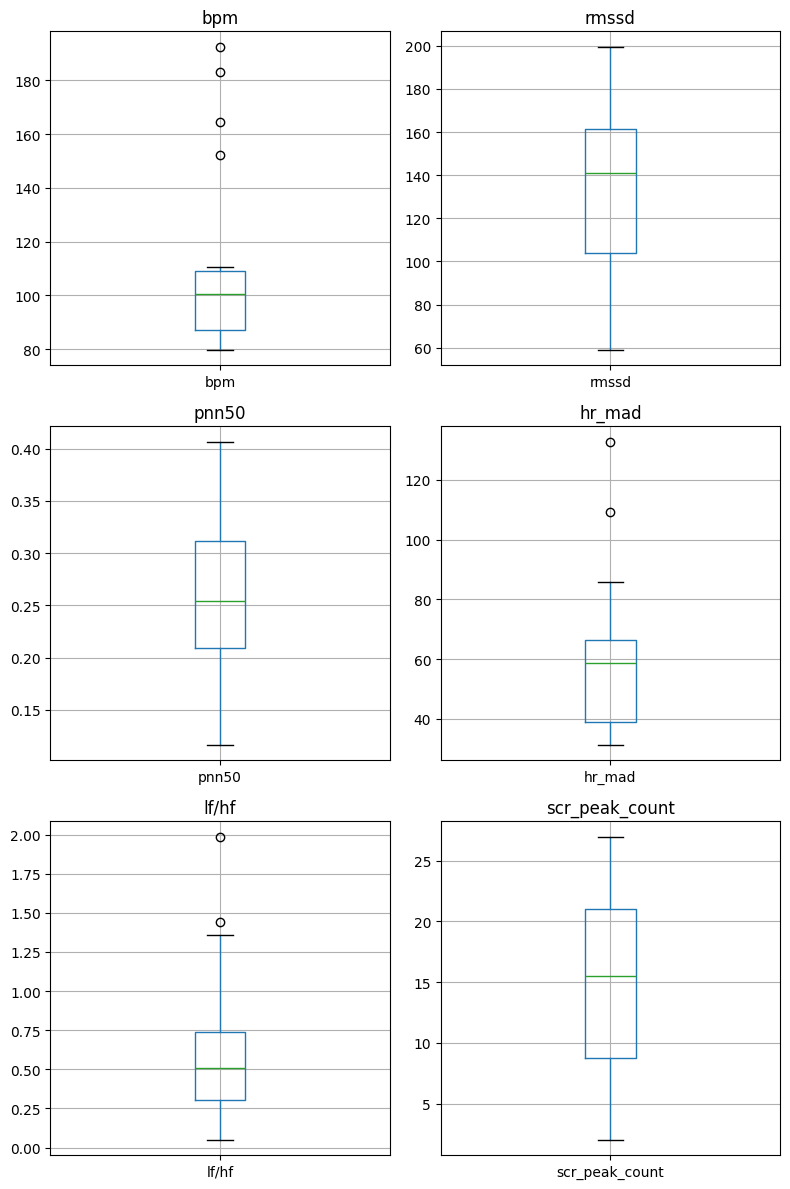

In [471]:
import math

# Suponiendo que tu df es basal_outlier_treated
# 1. Quitar columna no numérica
num = tscene_feat_mat.drop(columns=['Subject'], errors='ignore').select_dtypes(include='number')

# 2. Número de columnas a graficar
n_cols = num.shape[1]

# 3. Ajustar layout: 3 filas y las columnas necesarias
n_rows = 3
n_cols_per_row = math.ceil(n_cols / n_rows)

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(4*n_cols_per_row, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num.columns):
    num.boxplot(column=col, ax=axes[i], showfliers=True)  # muestra outliers
    axes[i].set_title(col)

# Si sobran ejes vacíos, los apagamos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [472]:
basal_feat_mat

,Subject,bpm,rmssd,pnn50,hr_mad,lf/hf,scr_peak_count
0,1,62.466476,58.491992,0.136986,39.0625,0.953789,17
1,1,63.840399,67.652525,0.126582,46.8750,1.086370,17
2,1,67.908512,86.004657,0.121622,62.5000,1.049084,18
3,1,68.746803,62.814230,0.145161,62.5000,0.492776,15
4,2,71.431793,54.698887,0.102041,46.8750,1.227310,74
5,2,74.250000,58.271328,0.091837,46.8750,0.744301,78
6,2,77.111562,64.847496,0.102041,62.5000,2.173484,26
7,2,85.404504,111.293637,0.189873,54.6875,2.263169,22
8,3,81.923703,50.081731,0.128205,31.2500,0.589342,35
9,3,85.128820,51.950588,0.100000,31.2500,0.674984,36


In [473]:
tscene_feat_mat

,Subject,bpm,rmssd,pnn50,hr_mad,lf/hf,scr_peak_count
0,1,164.365971,149.818175,0.303797,85.9375,0.629376,20
1,1,183.067203,163.549030,0.292683,78.1250,0.413989,26
2,1,192.642140,118.198472,0.258427,62.5000,0.048507,16
3,1,152.102377,139.412634,0.296875,109.3750,0.212171,5
4,2,91.596330,146.432282,0.218750,31.2500,0.217561,9
5,2,92.530120,182.116099,0.245283,39.0625,0.107688,10
6,2,103.572519,199.674841,0.250000,62.5000,0.103200,27
7,2,100.702622,177.532013,0.211538,46.8750,0.287193,20
8,3,109.990557,115.772710,0.122222,62.5000,0.508410,6
9,3,110.678383,115.461179,0.135802,39.0625,0.362833,15


In [474]:
def remove_outliers_iqr(data, df_calibration, p_low=0.05, p_high=0.95):
    q1 = df_calibration.quantile(p_low)
    q3 = df_calibration.quantile(p_high)
    iqr = df_calibration.apply(stats.iqr)
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[~((data < lower) | (data > upper)).any(axis=1)]


def remove_outliers_zscore(data, df_calibration):
    mean = df_calibration.mean()
    std = df_calibration.std()
    return data[np.abs(data-mean)<=(3*std)].dropna(axis=0,how='any')


def remove_outliers_winsor(col, p_low=0.05, p_high=0.95, treatment="impute"):
    lower = col.quantile(p_low)
    upper = col.quantile(p_high)
    return col.clip(lower=lower, upper=upper)


channel_cols = [col for col in basal_feat_mat.columns if col not in ["Subject"]]

## Baseline outlier treatment
basal_outlier_treated = basal_feat_mat.copy()
    
if outliermeth == 'winsor_outlier':
    basal_outlier_treated[channel_cols] = basal_feat_mat[channel_cols].apply(
        lambda s: remove_outliers_winsor(s, p_low=0.05, p_high=0.95)
    )
elif outliermeth == 'zscore_outlier':
    # basal_outlier_treated[channel_cols] = basal_feat_mat[channel_cols].apply(
    #     lambda s: remove_outliers_zscore(s, s)
    # )
    basal_outlier_treated[channel_cols] = remove_outliers_zscore(basal_feat_mat[channel_cols], basal_feat_mat[channel_cols])
elif outliermeth == 'quant_outlier':
    # basal_outlier_treated[channel_cols] = basal_feat_mat[channel_cols].apply(
    #     lambda s: remove_outliers_iqr(s, s, p_low=0.05, p_high=0.95, treatment=outliertreatment)
    # )
    basal_outlier_treated[channel_cols] = remove_outliers_iqr(basal_feat_mat[channel_cols], basal_feat_mat[channel_cols])


## Target scene outlier treatment
tscene_outlier_treated = tscene_feat_mat.copy()

if outliermeth == 'winsor_outlier':
    tscene_outlier_treated[channel_cols] = tscene_feat_mat[channel_cols].apply(
        lambda s: remove_outliers_winsor(s, p_low=0.1, p_high=0.9)
    )
elif outliermeth == 'zscore_outlier':
    # tscene_outlier_treated[channel_cols] = tscene_feat_mat[channel_cols].apply(
    #     lambda s: remove_outliers_zscore(s, basal_feat_mat[s.name])
    # )
    tscene_outlier_treated[channel_cols] = remove_outliers_zscore(tscene_feat_mat[channel_cols], basal_feat_mat[channel_cols])
    
elif outliermeth == 'quant_outlier':
    # tscene_outlier_treated[channel_cols] = tscene_feat_mat[channel_cols].apply(
    #     lambda s: remove_outliers_iqr(s, basal_feat_mat[s.name], p_low=0.05, p_high=0.95, treatment=outliertreatment)
    # )
    tscene_outlier_treated[channel_cols] = remove_outliers_iqr(tscene_feat_mat[channel_cols], basal_feat_mat[channel_cols])

basal_outlier_treated.dropna(inplace=True)
tscene_outlier_treated.dropna(inplace=True)

In [475]:
basal_outlier_treated

,Subject,bpm,rmssd,pnn50,hr_mad,lf/hf,scr_peak_count
0,1,62.466476,58.491992,0.136986,39.0625,0.953789,17
1,1,63.840399,67.652525,0.126582,46.8750,1.086370,17
2,1,67.908512,86.004657,0.121622,62.5000,1.049084,18
3,1,68.746803,62.814230,0.145161,62.5000,0.492776,15
4,2,71.431793,54.698887,0.102041,46.8750,1.227310,74
5,2,74.250000,58.271328,0.091837,46.8750,0.744301,78
6,2,77.111562,64.847496,0.102041,62.5000,2.173484,26
7,2,85.404504,111.293637,0.189873,54.6875,2.263169,22
8,3,81.923703,50.081731,0.128205,31.2500,0.589342,35
9,3,85.128820,51.950588,0.100000,31.2500,0.674984,36


In [476]:
tscene_outlier_treated

,Subject,bpm,rmssd,pnn50,hr_mad,lf/hf,scr_peak_count
4,2,91.596330,146.432282,0.218750,31.2500,0.217561,9.0
5,2,92.530120,182.116099,0.245283,39.0625,0.107688,10.0
6,2,103.572519,199.674841,0.250000,62.5000,0.103200,27.0
7,2,100.702622,177.532013,0.211538,46.8750,0.287193,20.0
8,3,109.990557,115.772710,0.122222,62.5000,0.508410,6.0
9,3,110.678383,115.461179,0.135802,39.0625,0.362833,15.0
10,3,109.534426,142.400373,0.116279,31.2500,0.379011,8.0
11,3,109.040675,165.975173,0.150685,54.6875,0.307176,8.0
12,4,87.975831,91.301950,0.200000,31.2500,1.440431,21.0
13,4,87.876530,96.184685,0.258824,54.6875,0.708776,24.0


In [477]:
list(tscene_outlier_treated['Subject'].unique())

[2, 3, 4, 6, 8, 9]

In [478]:
def norm_with_ref(
    subjects,
    feat_mat,
    ref_mat,
    normtype=str,
):
    channel_cols = [col for col in ref_mat.columns if col not in ["Subject"]]

    normdata_list = []

    # Data is normalized per subject 
    for subject in subjects:
        data = feat_mat[feat_mat["Subject"] == subject].copy()

        ref_data = ref_mat[ref_mat["Subject"] == subject].copy().drop("Subject", axis=1)


        if normtype == "zscore":
            scaler = StandardScaler()
            scaler.fit(ref_data[channel_cols])
            data[channel_cols] = scaler.transform(data[channel_cols])
        elif normtype == "minmax":
            scaler = MinMaxScaler()
            scaler.fit(ref_data[channel_cols])
            data[channel_cols] = scaler.transform(data[channel_cols])
        normdata_list.append(data.dropna())
    normdata_df = pd.concat(normdata_list, ignore_index=True)

    return normdata_df

subjects = tscene_outlier_treated['Subject'].unique()
norm = norm_with_ref(
    subjects=subjects,
    feat_mat=tscene_outlier_treated,
    ref_mat=basal_outlier_treated,
    normtype=normtype,
)
norm

,Subject,bpm,rmssd,pnn50,hr_mad,lf/hf,scr_peak_count
0,2,2.784047,3.249822,2.449422,-3.316625,-2.162380,-1.572278
1,2,2.962761,4.813667,3.117348,-2.110579,-2.333985,-1.533930
2,2,5.076107,5.583180,3.236090,1.507557,-2.340995,-0.882010
3,2,4.526852,4.612770,2.267883,-0.904534,-2.053626,-1.150447
4,3,1.477089,0.468738,0.272946,1.732051,-0.890748,-4.031511
5,3,1.536848,0.461902,1.264219,0.000000,-2.412066,-2.700003
6,3,1.437460,1.053009,-0.160866,-0.577350,-2.243004,-3.735620
7,3,1.394563,1.570294,2.350545,1.154701,-2.993700,-3.735620
8,4,1.224928,2.848826,2.126451,-0.962250,5.828876,-0.319489
9,4,1.211073,3.385433,3.923618,0.192450,2.104176,-0.199681


In [479]:
outpath = os.path.join(base_dir, 'Outputs', f'outlier_{outliertreatment}', outliermeth)
basal_outlier_treated.to_csv(os.path.join(outpath,'non-normalized',rf'biometric_feat_mat_scene_{basalscene}_nonnorm.csv'), index=False)
tscene_outlier_treated.to_csv(os.path.join(outpath,'non-normalized',rf'biometric_feat_mat_scene_{targetscene}_nonnorm.csv'), index=False)
norm.to_csv(os.path.join(outpath, rf'biometric_feat_mat_scene_{targetscene}_{normtype}.csv'), index=False)

In [480]:
x_labels = ["Baseline"] + [f"Scene {i+1}" for i in range(5)]
x_labels

['Baseline', 'Scene 1', 'Scene 2', 'Scene 3', 'Scene 4', 'Scene 5']

In [481]:
x_labels

['Baseline', 'Scene 1', 'Scene 2', 'Scene 3', 'Scene 4', 'Scene 5']

In [482]:
print(x_labels)

['Baseline', 'Scene 1', 'Scene 2', 'Scene 3', 'Scene 4', 'Scene 5']


In [483]:
outpath

'C:\\Users\\josee\\OneDrive\\Documentos\\GitHub\\neurohumanities-lab\\OfflineProcessing\\Biometrics\\Outputs\\outlier_elim\\quant_outlier'